In [1]:
import warnings
warnings.filterwarnings('ignore')

In [2]:
#import required classes and packages
import os
import cv2
import numpy as np
from keras.utils.np_utils import to_categorical
from keras.layers import  MaxPooling2D
from keras.layers import Dense, Dropout, Activation, Flatten
from keras.layers import Convolution2D
from keras.models import Sequential, load_model, Model
import pickle
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
import keras
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt   
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
from sklearn import metrics 

Using TensorFlow backend.


In [3]:
#define and load class labels found in dataset
path = "Dataset"
labels = []
X = []
Y = []
for root, dirs, directory in os.walk(path):
    for j in range(len(directory)):
        name = os.path.basename(root)
        if name not in labels:
            labels.append(name.strip())   
print("Dataset Class Labels : "+str(labels))

Dataset Class Labels : ['FAKE', 'REAL']


In [4]:
#define function to get class label of given image
def getLabel(name):
    index = -1
    for i in range(len(labels)):
        if labels[i] == name:
            index = i
            break
    return index

In [5]:
#load dataset image and process them
if os.path.exists("model/X.txt.npy"):
    X = np.load('model/X.txt.npy')
    Y = np.load('model/Y.txt.npy')
else: #if images not process then read and process image pixels
    for root, dirs, directory in os.walk(path):#connect to dataset folder
        for j in range(len(directory)):#loop all images from dataset folder
            name = os.path.basename(root)
            if 'Thumbs.db' not in directory[j]:
                img = cv2.imread(root+"/"+directory[j])#read images
                img = cv2.resize(img, (32, 32))#resize image
                X.append(img) #add image pixels to X array
                label = getLabel(name)#get image label id
                Y.append(label)#add image label                
    X = np.asarray(X)#convert array as numpy array
    Y = np.asarray(Y)
    np.save('model/X.txt',X)#save process images and labels
    np.save('model/Y.txt',Y)
print("Dataset images loaded")
print("Total images found in dataset : "+str(X.shape[0]))
print()

Dataset images loaded
Total images found in dataset : 100000



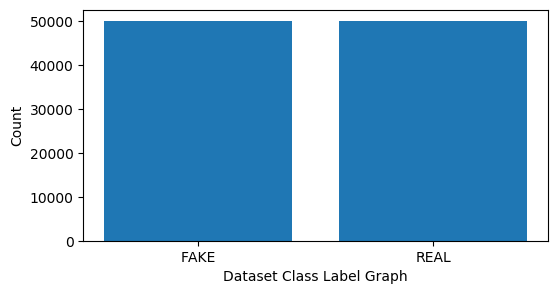

In [6]:
#visualizing class labels count found in dataset
names, count = np.unique(Y, return_counts = True)
height = count
bars = labels
y_pos = np.arange(len(bars))
plt.figure(figsize = (6, 3)) 
plt.bar(y_pos, height)
plt.xticks(y_pos, bars)
plt.xlabel("Dataset Class Label Graph")
plt.ylabel("Count")
plt.show()

In [7]:
#preprocess images like shuffling and normalization
X = X.astype('float32')
X = X/255 #normalized pixel values between 0 and 1
indices = np.arange(X.shape[0])
np.random.shuffle(indices)#shuffle all images
X = X[indices]
Y = Y[indices]
Y = to_categorical(Y)
#split dataset into train and test
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.2)
print("Dataset Image Processing & Normalization Completed")
print("80% images used to train algorithms : "+str(X_train.shape[0]))
print("20% image used to train algorithms : "+str(X_test.shape[0]))

Dataset Image Processing & Normalization Completed
80% images used to train algorithms : 80000
20% image used to train algorithms : 20000


In [8]:
#define global variables to save accuracy and other metrics
accuracy = []
precision = []
recall = []
fscore = []

In [9]:
#function to calculate all metrics
def calculateMetrics(algorithm, testY, predict):
    p = precision_score(testY, predict,average='macro') * 100
    r = recall_score(testY, predict,average='macro') * 100
    f = f1_score(testY, predict,average='macro') * 100
    a = accuracy_score(testY,predict)*100
    accuracy.append(a)
    precision.append(p)
    recall.append(r)
    fscore.append(f)
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" Precision : "+str(p))
    print(algorithm+" Recall    : "+str(r))
    print(algorithm+" FSCORE    : "+str(f))
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 3))
    ax = sns.heatmap(conf_matrix, xticklabels = labels, yticklabels = labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 

    random_probs = [0 for i in range(len(testY))]
    p_fpr, p_tpr, _ = roc_curve(testY, random_probs, pos_label=1)
    plt.plot(p_fpr, p_tpr, linestyle='--', color='orange',label="True classes")
    ns_fpr, ns_tpr, _ = roc_curve(testY, predict, pos_label=1)
    axs[1].plot(ns_fpr, ns_tpr, linestyle='--', label='Predicted Classes')
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    plt.show()



Propose CNN2D Accuracy  : 94.965
Propose CNN2D Precision : 94.99042304963722
Propose CNN2D Recall    : 94.98369812910148
Propose CNN2D FSCORE    : 94.96496977723108


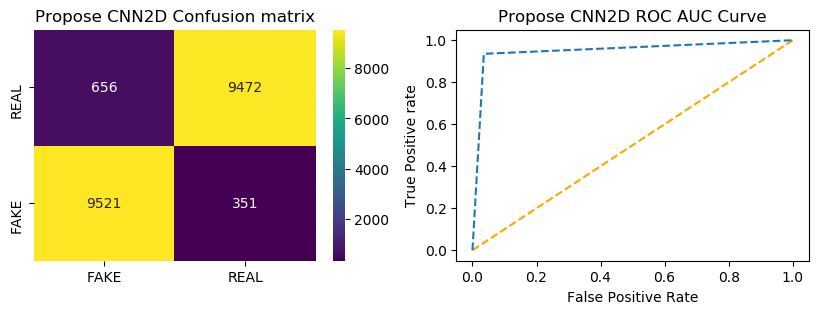

In [10]:
#train CNN algorithm with best tuning parameters such as 32 as the number of neurons and 3 different layers
#CNN architecure consists of two layers of CNN2D, MaxPooling2D and Dense
#author has done experiment with different nuerons but 32 neurons giving best accuracy so we have used CNN with 32 neurons
cnn_model = Sequential()
#defining first CNN2D layer of size 32 with 3X3 matrix to filter features
cnn_model.add(Convolution2D(32, (3, 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
#max layer will collect relevant features from CNN2D
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
#Defining another layer of same number of neurons
cnn_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
cnn_model.add(MaxPooling2D(pool_size = (2, 2)))
cnn_model.add(Flatten())
#defining dense layer
cnn_model.add(Dense(units = 256, activation = 'relu'))
cnn_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
cnn_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/cnn_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/cnn_weights.hdf5', verbose = 1, save_best_only = True)
    hist = cnn_model.fit(X_train, y_train, batch_size = 32, epochs = 15, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/cnn_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    cnn_model.load_weights("model/cnn_weights.hdf5")
#perform prediction on test data   
predict = cnn_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function with true and predicted class labels to calculate accuracy and other metrics
calculateMetrics("Propose CNN2D", y_test1, predict)

Extension Modified CNN2D Accuracy  : 95.92500000000001
Extension Modified CNN2D Precision : 95.98552776897165
Extension Modified CNN2D Recall    : 95.90442498098889
Extension Modified CNN2D FSCORE    : 95.92172219636797


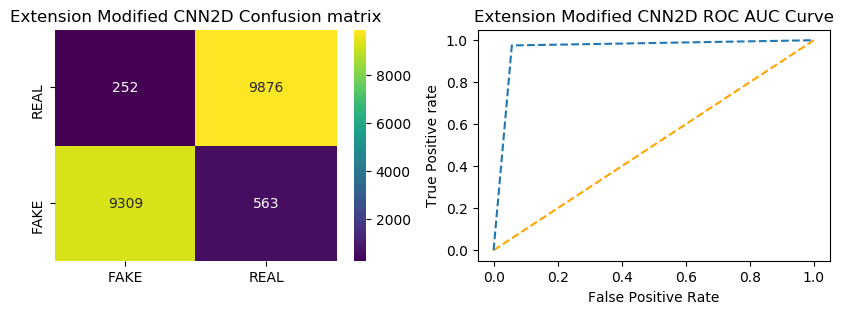

In [11]:
#in propose algorithm author has used only CNN2D and maxpool layer but not provided any other layer which will further
#removed irrelevant features to enhance accuracy so in same architecture as extension we have added another layer called 
#Dropout to remove all irrelevant features so model get only optimize features to enhnace accuracy
extension_model = Sequential()
extension_model.add(Convolution2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (2, 2)))
#for each CNN2d and Maxpool layer we have connected dropout layer to remove all irrelevant features
extension_model.add(Dropout(0.3))
extension_model.add(Convolution2D(32, (3, 3), activation = 'relu'))
extension_model.add(MaxPooling2D(pool_size = (2, 2)))
#adding another dropout layer for CNN and max layer
extension_model.add(Dropout(0.3))
extension_model.add(Flatten())
extension_model.add(Dense(units = 256, activation = 'relu'))
extension_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
extension_model.compile(optimizer = 'adam', loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/extension_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/extension_weights.hdf5', verbose = 1, save_best_only = True)
    hist = extension_model.fit(X_train, y_train, batch_size = 32, epochs = 15, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/extension_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    extension_model.load_weights("model/extension_weights.hdf5")
#perform prediction on test data
predict = extension_model.predict(X_test)
predict = np.argmax(predict, axis=1)
y_test1 = np.argmax(y_test, axis=1)
#call this function with true and predicted class labels to calculate accuracy and other metrics
calculateMetrics("Extension Modified CNN2D", y_test1, predict)

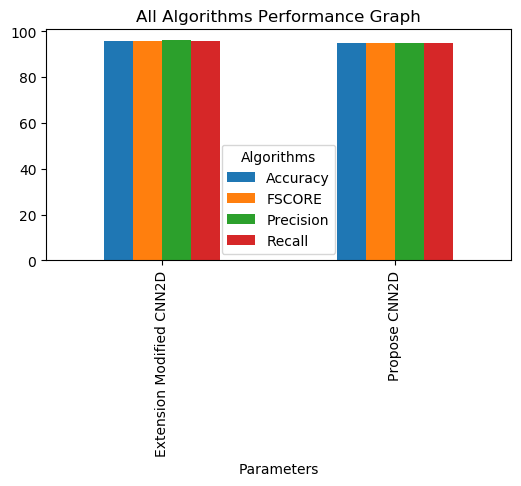

In [12]:
#plot all algorithm performance in tabukar format
import pandas as pd
df = pd.DataFrame([['Propose CNN2D','Accuracy',accuracy[0]],['Propose CNN2D','Precision',precision[0]],['Propose CNN2D','Recall',recall[0]],['Propose CNN2D','FSCORE',fscore[0]],
                   ['Extension Modified CNN2D','Accuracy',accuracy[1]],['Extension Modified CNN2D','Precision',precision[1]],['Extension Modified CNN2D','Recall',recall[1]],['Extension Modified CNN2D','FSCORE',fscore[1]],
                  ],columns=['Parameters','Algorithms','Value'])
df.pivot("Parameters", "Algorithms", "Value").plot(kind='bar', figsize=(6, 3))
plt.title("All Algorithms Performance Graph")
plt.show()

In [13]:
#display all algorithm performnace
algorithms = ['Propose CNN2D', 'Extension Modified CNN2D']
data = []
for i in range(len(accuracy)):
    data.append([algorithms[i], accuracy[i], precision[i], recall[i], fscore[i]])
data = pd.DataFrame(data, columns=['Algorithm Name', 'Accuracy', 'Precision', 'Recall', 'FSCORE'])
data  

,Algorithm Name,Accuracy,Precision,Recall,FSCORE
0,Propose CNN2D,94.965,94.990423,94.983698,94.964970
1,Extension Modified CNN2D,95.925,95.985528,95.904425,95.921722


In [14]:
def GradCamImage(image_path, ext_model):
    grad_cam = Model(inputs = ext_model.inputs, outputs = ext_model.layers[0].output)
    image = cv2.imread(image_path)
    img = cv2.resize(image, (32, 32))
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)
    img = np.asarray(im2arr)
    img = img.astype('float32')
    img = img/255
    preds = grad_cam.predict(img)[0]
    return preds

In [15]:
#use this function to predict fish species uisng extension model
def predict(image_path):
    image = cv2.imread(image_path)#read test image
    img = cv2.resize(image, (32, 32))#resize image
    im2arr = np.array(img)
    im2arr = im2arr.reshape(1,32,32,3)#convert image as 4 dimension
    img = np.asarray(im2arr)
    img = img.astype('float32')#convert image features as float
    img = img/255 #normalized image
    predict = extension_model.predict(img)#now predict dog breed
    predict = np.argmax(predict)
    grad_cam = GradCamImage(image_path, extension_model)
    img = cv2.imread(image_path)
    img = cv2.resize(img, (500,300))#display image with predicted output
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    cv2.putText(img, 'Predicted As : '+labels[predict], (10, 25),  cv2.FONT_HERSHEY_SIMPLEX,0.7, (255, 0, 0), 2)
    figure, axis = plt.subplots(nrows=1, ncols=2, figsize=(10, 6))
    axis[0].set_title("Original Image")
    axis[1].set_title("Explainable Grad-Cam Image")
    axis[0].imshow(img, cmap='hot')
    axis[1].imshow(grad_cam[:,:,31], cmap='hot')
    plt.axis('off')
    plt.show()

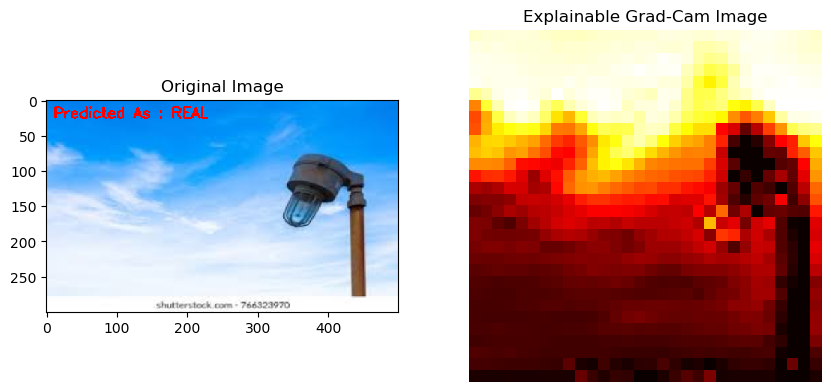

In [16]:
#call this function with test image to predict dog breed
predict("testImages/test2.jpg")

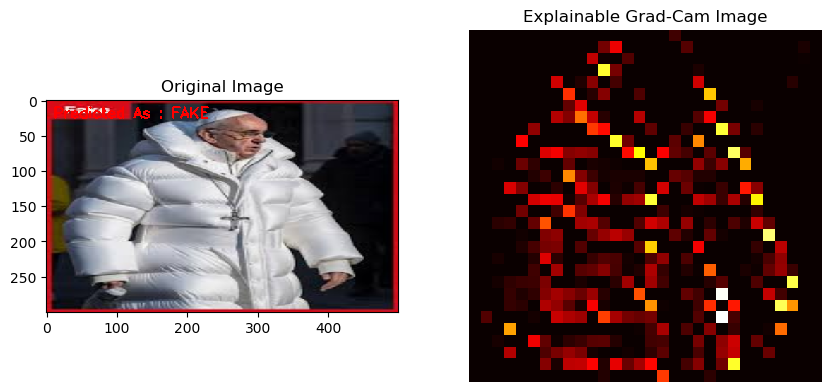

In [17]:
#call this function with test image to predict dog breed
predict("testImages/test.jpg")

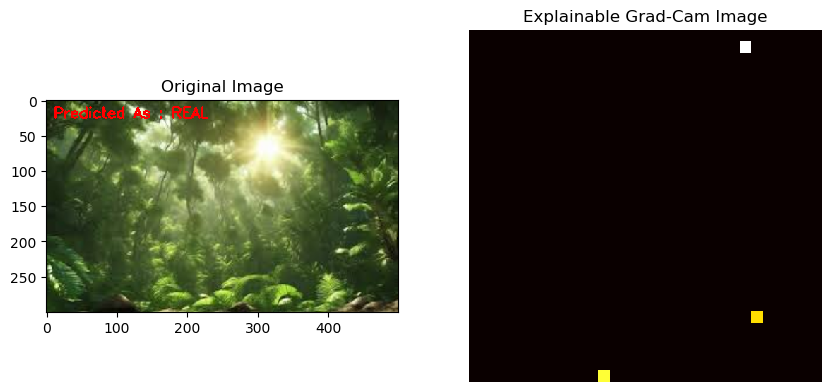

In [18]:
#call this function with test image to predict dog breed
predict("testImages/test3.jpg")